In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Cargar la base de datos a nuesstro codigo, definir nuestro train y test, y eliminar las variables que no vamos a usar para este análisis, como la variable de salida "Baja General" así como otras varaibles que pueden afectar al clustering, como el motivo de baja oe status. Adicionalmente, se eliminaron las variables relacionadas a fechas debido a las discrepancias que surgieron en el análisis

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# -----------------------------
# 1️⃣ Cargar y preparar datos
# -----------------------------
file_path1 = '/content/drive/MyDrive/Datos_train_ns.csv'
file_path2 = '/content/drive/MyDrive/Datos_test_ns.csv'

Train = pd.read_csv(file_path1)
Test = pd.read_csv(file_path2)

# Eliminar columnas irrelevantes
cols_to_drop = ['Edad_en_fecha_de_registro_dias', 'Edad en años',
                'Fecha de nacimiento en dias', 'Fecha de evaluación_num']

X_train = Train.drop(columns=cols_to_drop)
X_test = Test.drop(columns=cols_to_drop)

# Separar la variable de salida
y_train = X_train[['Baja General','Motivo de baja','Tipo', 'Estatus']]
y_test = X_test[['Baja General', 'Motivo de baja', 'Tipo', 'Estatus']]

X_train = X_train.drop(columns=['Baja General', 'Motivo de baja', 'Tipo', 'Estatus'])
X_test = X_test.drop(columns=['Baja General', 'Motivo de baja', 'Tipo', 'Estatus'])

X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 939 entries, 0 to 938
Data columns (total 34 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Matrícula                                 939 non-null    float64
 1   Número de hermanos en la familia          939 non-null    float64
 2   Ingresos por apoyo gubernamental          939 non-null    float64
 3   Total de ingresos mensuales               939 non-null    float64
 4   Total de egresos                          939 non-null    float64
 5   Ingreso Per Cápita                        939 non-null    float64
 6   Porcentaje de Beca                        939 non-null    float64
 7   Sexo                                      939 non-null    object 
 8   Programa                                  939 non-null    object 
 9   Grupo                                     939 non-null    object 
 10  Inscripción / Reinscripción           

2. Realizar un preprocesamiento de los datos sencillo, donde se escalen las variables numericas para facilitar su análisis, y se codifican las las categoricas, es decir, se obtienen sus dummies

In [ ]:
# Separar tipos de variables
X_num = X_train.select_dtypes(include=['float64'])
X_bool = X_train.select_dtypes(include=['int64'])       # booleanas
X_cat = X_train.select_dtypes(include=['object'])       # categóricas

# Escalar solo las numéricas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_num.columns, index=X_train.index)

# Codificar categóricas
X_encoded = pd.get_dummies(X_cat, drop_first=True)

# Unir todo
X_final = pd.concat([X_scaled_df, X_bool, X_encoded], axis=1)
print("Shape final del dataset procesado:", X_final.shape)

Shape final del dataset procesado: (939, 448)


3. Se realiza un PCA para poder hacer el clustering correctamente, tomando el 80% de los datos originales para generar el PCA. El pca generado fue de 48 componentes. La grafica impresa muestra la catnidad de componentes necesarios para representar el porcentaje requerido de los datos

In [ ]:
pca = PCA(n_components=0.80)
X_pca = pca.fit_transform(X_final)

print(f"Componentes principales retenidos: {X_pca.shape[1]}")

Componentes principales retenidos: 48


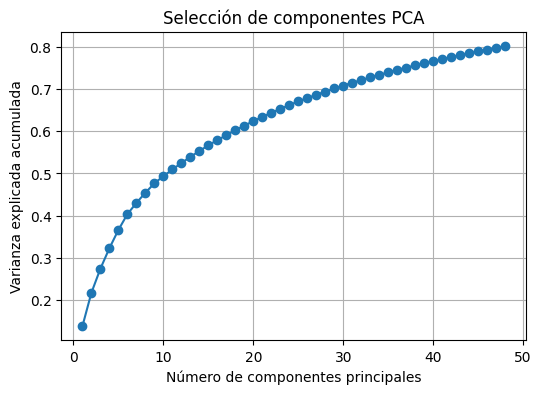

In [ ]:
# Visualizar varianza explicada
plt.figure(figsize=(6,4))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_.cumsum(), marker='o')
plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza explicada acumulada')
plt.title('Selección de componentes PCA')
plt.grid(True)
plt.show()

4. Se realiza el proceso de clustering utilizando la libreria Kmeans, se decidieron 4 clusters en base a los datos. Como solo tenemos dos grupos, Baja y Alta, se crearonn un numero cercano de clusters a 2, pero si mayor con la intención de encontrar separaciones mas especificas

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_pca)

5. Se vuelve a cargar la información pero sin imputación, para un análisis mas correcto a la hora de utilizar Odss Ratio y análisis estadístico para encontrar las variables significativas

In [ ]:

file_path2 = '/content/drive/MyDrive/Datos_train_ns (1).csv'
file_path3 = '/content/drive/MyDrive/Datos_test_ns (1).csv'

Train = pd.read_csv(file_path2)
Test = pd.read_csv(file_path3)

# Eliminar columnas irrelevantes
cols_to_drop = ['Edad_en_fecha_de_registro_dias', 'Edad en años',
                'Fecha de nacimiento en dias', 'Fecha de evaluación_num']

X_train = Train.drop(columns=cols_to_drop)
X_test = Test.drop(columns=cols_to_drop)


# Separar la variable de salida
y_train = Train[['Baja General','Motivo de baja','Tipo', 'Estatus']]
y_test = Test[['Baja General', 'Motivo de baja', 'Tipo', 'Estatus']]

X_train = X_train.drop(columns=['Baja General', 'Motivo de baja', 'Tipo', 'Estatus'])
X_test = X_test.drop(columns=['Baja General', 'Motivo de baja', 'Tipo', 'Estatus'])

X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 939 entries, 0 to 938
Data columns (total 51 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Matrícula                                 939 non-null    int64  
 1   Sexo                                      865 non-null    object 
 2   Programa                                  939 non-null    object 
 3   Grupo                                     314 non-null    object 
 4   Inscripción / Reinscripción               939 non-null    object 
 5   Transporte del INA                        349 non-null    object 
 6   Clínica de Adscripción en el IMSS         461 non-null    object 
 7   Inst. en la que reciben servicio médico   876 non-null    object 
 8   Ciudad                                    939 non-null    object 
 9   Estado                                    939 non-null    object 
 10  Hospital donde nació                  

6. Se asigna el cluster creado anteriormente a cada dato dentro de la nueva base de datos, y se realiza un análisis exploratoria inicial, donde se observa el porcetaje de bajas y altas dentro de cada cluster. Esto busca detectar si hay diferencias significativas entre proporciones, cosa que no se dio particularmente.

In [ ]:
df_clusters = X_train.copy()
df_clusters['Cluster'] = clusters

# Agregar todas las columnas de y_train
df_clusters = pd.concat([df_clusters, y_train.reset_index(drop=True)], axis=1)


In [ ]:


## a) Distribución de bajas por cluster
print("\nDistribución de bajas/altas por cluster:")
print(df_clusters.groupby('Cluster')['Baja General'].value_counts(normalize=True))


Distribución de bajas/altas por cluster:
Cluster  Baja General
0        True            0.648903
         False           0.351097
1        True            0.638298
         False           0.361702
2        True            0.683698
         False           0.316302
3        True            0.705882
         False           0.294118
Name: proportion, dtype: float64


7. Usando dos de las variables PCA creadas, se hace una visualización de como se distribuyen los datos en cuanto a los clusters. Con esta gráfica lo que queremos ver es que tan juntos o mezclados estan un cluster con el otro. Optimamente, los clusters deben de estar bien separados, pues entonces tenemos diferencias mejor definidas

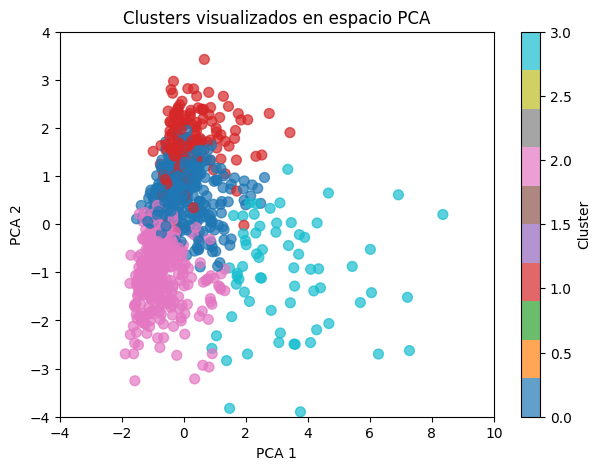

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='tab10', s=50, alpha=0.7)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.xlim(-4, 10)
plt.ylim(-4, 4)
plt.title('Clusters visualizados en espacio PCA')
plt.colorbar(label='Cluster')
plt.show()

Se instala la libreria necesaria para análisis estadístico

In [ ]:
!pip install scikit-posthocs


8. Empezamos con el proceso de análisis estadístico, generando una prueba estadística U para las variables numéricas en cada cluster vs los demas, con un p-ajustado para mayor rigurozidad, con el objetivo de encontrar variables que sean significativamente diferentes en un cluster respecto a los demas. Para las variables categoricas se usa la pruba de Chi-cuadrado, con el mismo propósito.

In [ ]:
from scipy.stats import mannwhitneyu, chi2_contingency
import numpy as np

print(" PRUEBAS CLUSTER vs. RESTO (NUMÉRICAS)\n")
num_cluster_results = []

clusters = sorted(df_clusters['Cluster'].unique())

for col in X_num.columns:
    for c in clusters:
        grupo_c = df_clusters.loc[df_clusters['Cluster'] == c, col].dropna()
        grupo_rest = df_clusters.loc[df_clusters['Cluster'] != c, col].dropna()
        if len(grupo_c) > 1 and len(grupo_rest) > 1:
            stat, p = mannwhitneyu(grupo_c, grupo_rest, alternative='two-sided')
            num_cluster_results.append({'Variable': col, 'Cluster': c, 'Estadístico U': stat, 'p-valor': p})

num_cluster_df = pd.DataFrame(num_cluster_results)
num_cluster_df['p-ajustado'] = np.minimum(num_cluster_df['p-valor'] * len(num_cluster_df), 1.0)  # Bonferroni
num_cluster_df = num_cluster_df.sort_values(by='p-ajustado')
print(num_cluster_df)


🔹 PRUEBAS CLUSTER vs. RESTO (NUMÉRICAS)

                            Variable  Cluster  Estadístico U   p-valor  \
7   Número de hermanos en la familia        3        30227.5  0.007140   
0                          Matrícula        0       102248.0  0.393657   
2                          Matrícula        2       110212.0  0.678770   
1                          Matrícula        1        53440.0  0.342434   
3                          Matrícula        3        27367.0  0.296965   
4   Número de hermanos en la familia        0        86301.0  0.509568   
5   Número de hermanos en la familia        1        50491.5  0.894522   
6   Número de hermanos en la familia        2        93791.0  0.402822   
8   Ingresos por apoyo gubernamental        0        84439.5  0.122636   
9   Ingresos por apoyo gubernamental        1        49896.5  0.503794   
10  Ingresos por apoyo gubernamental        2       103930.5  0.087708   
11  Ingresos por apoyo gubernamental        3        25795.5  0.624725 

In [ ]:

print("\n PRUEBAS CLUSTER vs. RESTO (CATEGÓRICAS)\n")
cat_cluster_results = []

for col in X_cat.columns:
    for c in clusters:
        sub_df = df_clusters.copy()
        sub_df['Grupo'] = np.where(sub_df['Cluster'] == c, f'Cluster_{c}', 'Otros')
        tabla = pd.crosstab(sub_df['Grupo'], sub_df[col])
        chi2, p, dof, ex = chi2_contingency(tabla)
        cat_cluster_results.append({'Variable': col, 'Cluster': c, 'Chi2': chi2, 'p-valor': p})

cat_cluster_df = pd.DataFrame(cat_cluster_results)
cat_cluster_df['p-ajustado'] = np.minimum(cat_cluster_df['p-valor'] * len(cat_cluster_df), 1.0)
cat_cluster_df = cat_cluster_df.sort_values(by='p-ajustado')
print(cat_cluster_df)


🔸 PRUEBAS CLUSTER vs. RESTO (CATEGÓRICAS)

                Variable  Cluster        Chi2        p-valor     p-ajustado
10                 Grupo        2  934.941315  2.489761e-205  2.390171e-203
8                  Grupo        0  934.547202  3.032701e-205  2.911393e-203
9                  Grupo        1  931.180083  1.635958e-204  1.570520e-202
11                 Grupo        3  924.172109  5.459731e-203  5.241342e-201
38  Hospital donde nació        2   29.000096   1.246000e-03   1.196160e-01
..                   ...      ...         ...            ...            ...
91           Nivel GMFCS        3    5.205746   2.668306e-01   1.000000e+00
92       Categoria_Lugar        0    5.008187   8.174969e-02   1.000000e+00
93       Categoria_Lugar        1    1.368837   5.043834e-01   1.000000e+00
94       Categoria_Lugar        2    2.136279   3.436473e-01   1.000000e+00
95       Categoria_Lugar        3    0.162707   9.218678e-01   1.000000e+00

[96 rows x 5 columns]


9. Se genera un resumen respecto a los resultados, donde podemos observar las variables categoricas que dieron significativamente diferentes en un cluster.

In [ ]:

print("\n RESUMEN DE RESULTADOS SIGNIFICATIVOS\n")

for df, tipo in [(num_cluster_df, "Numéricas"), (cat_cluster_df, "Categóricas")]:
    print(f"\n--- {tipo} ---")
    signif = df[df['p-valor'] < 0.05]
    if signif.empty:
        print("No se encontraron diferencias significativas.")
    else:
        for _, row in signif.iterrows():
            print(f"Variable: {row['Variable']} | Cluster {row['Cluster']} diferente del resto (p-ajustado={row['p-valor']:.3e})")


🔹 RESUMEN DE RESULTADOS SIGNIFICATIVOS


--- Numéricas ---
Variable: Número de hermanos en la familia | Cluster 3 diferente del resto (p-ajustado=7.140e-03)

--- Categóricas ---
Variable: Grupo | Cluster 2 diferente del resto (p-ajustado=2.490e-205)
Variable: Grupo | Cluster 0 diferente del resto (p-ajustado=3.033e-205)
Variable: Grupo | Cluster 1 diferente del resto (p-ajustado=1.636e-204)
Variable: Grupo | Cluster 3 diferente del resto (p-ajustado=5.460e-203)
Variable: Hospital donde nació | Cluster 2 diferente del resto (p-ajustado=1.246e-03)
Variable: Diagnostico Fisiologico | Cluster 2 diferente del resto (p-ajustado=7.088e-03)
Variable: Transporte del INA | Cluster 2 diferente del resto (p-ajustado=1.698e-02)
Variable: Inst. en la que reciben servicio médico | Cluster 0 diferente del resto (p-ajustado=3.729e-02)
Variable: Nivel GMFCS | Cluster 0 diferente del resto (p-ajustado=1.889e-02)


10. Siguiendo un procedimiento parecido, comparamos numericamente la cantidad de bajas y altas en cada cluster, para ver que tanto difieren. Los reusltados arrojan que son practicamente iguales, por lo que no habra diferencias a notar entre clusters. Tras realizar esto, se hizo un análisis de Odds Ratio, que busca observar que tan probable es que un alumno se de de baja dado que no pertenece a los otros clusters. Estos resultados no dieron datos concisos, pues para que un dato sea valido el OR tiene que mantenerse o abajo de 1 o arriba de 1 en ambos limites de sus intervalos de confianza.

In [ ]:
from scipy.stats import fisher_exact
import numpy as np
import pandas as pd

# Crear tabla de contingencia
tabla = pd.crosstab(df_clusters["Cluster"], df_clusters["Baja General"])

# Calcular odds ratio para cada cluster vs referencia
odds_ratios = []
ref_cluster = 0

for cl in tabla.index:
    if cl == ref_cluster:
        continue

    a = tabla.loc[ref_cluster, True]
    b = tabla.loc[ref_cluster, False]
    c = tabla.loc[cl, True]
    d = tabla.loc[cl, False]

    # Add a small epsilon to avoid division by zero if d is 0
    epsilon = 1e-9
    OR = (c / (d + epsilon)) / (a / (b + epsilon))

    se = np.sqrt(1/a + 1/b + 1/c + 1/(d + epsilon))
    ci_lower = np.exp(np.log(OR) - 1.96 * se)
    ci_upper = np.exp(np.log(OR) + 1.96 * se)

    odds_ratios.append({
        "Comparación": f"{cl} vs {ref_cluster}",
        "Odds Ratio": OR,
        "IC 95% inf": ci_lower,
        "IC 95% sup": ci_upper
    })

odds_df = pd.DataFrame(odds_ratios)
print(tabla)
print(odds_df)

Baja General  False  True 
Cluster                   
0               112    207
1                51     90
2               130    281
3                20     48
  Comparación  Odds Ratio  IC 95% inf  IC 95% sup
0      1 vs 0    0.954817    0.631537    1.443580
1      2 vs 0    1.169528    0.857814    1.594514
2      3 vs 0    1.298551    0.734317    2.296329


11. Ahora hacemos este mismo analiss de OR pero para las variables significativas en cada cluster. Solo se realizo el análisis en variables categoricas, al solo tener una variable numérica significativa y ser mas complicada de presentar en un analisis de OR. Para las categoricas, se analiza en base a la cateogria especifica que dio significativa, observando que tan probable es que un alumno se de de baja dado que pertenezca a esta categoría y no a las demas, dentro de su respectivo cluster. Los resultados de este análisis muestran como resultado as destacable que quizas la Categoria V en el Nivel GMFCS puede presentar un riesgo mayor a las demas de darse de baja en todos los casos, por lo que se sigue un análisis final respecto a esta variable.

In [ ]:
import numpy as np
import pandas as pd

resultados_or = []

# Define vars_signif_cat from previous analysis
signif_cat = cat_cluster_df[cat_cluster_df['p-valor'] < 0.05]
vars_signif_cat = signif_cat['Variable'].unique().tolist()

for cl in sorted(df_clusters["Cluster"].unique()):
    df_cl = df_clusters[df_clusters["Cluster"] == cl]

    for var in vars_signif_cat:   # solo variables significativas
        if var not in df_cl.columns:
            continue

        # Eliminar NaNs SOLO para este análisis
        temp = df_cl[[var, "Baja General"]].dropna()

        # Necesitamos al menos dos categorías
        if temp[var].nunique() < 2:
            continue

        # One-vs-rest para múltiples categorías
        for cat in temp[var].unique():
            temp_bin = temp.copy()
            temp_bin["bin_cat"] = np.where(temp_bin[var] == cat, cat, "Otros")

            tabla = pd.crosstab(temp_bin["bin_cat"], temp_bin["Baja General"])

            if tabla.shape != (2, 2):
                continue

            a = tabla.iloc[0, 1]
            b = tabla.iloc[0, 0]
            c = tabla.iloc[1, 1]
            d = tabla.iloc[1, 0]

            if min(a, b, c, d) == 0:
                continue

            OR = (a / b) / (c / d)
            se = np.sqrt(1/a + 1/b + 1/c + 1/d)
            ci_low = np.exp(np.log(OR) - 1.96 * se)
            ci_high = np.exp(np.log(OR) + 1.96 * se)

            resultados_or.append({
                "Cluster": cl,
                "Variable": var,
                "Categoría": cat,
                "Odds Ratio": OR,
                "IC 95% inf": ci_low,
                "IC 95% sup": ci_high,
                "N usados": len(temp_bin)
            })

odds_ratio_df = pd.DataFrame(resultados_or)

# Collect indices to drop before dropping to avoid errors during iteration
indices_to_drop = []
for i in odds_ratio_df.index:
  # This condition keeps rows where the upper bound of the CI is <= 1
  # which means it filters out cases where OR > 1 or CI crosses 1
  if odds_ratio_df.loc[i]['IC 95% sup'] > 1:
    indices_to_drop.append(i)

# Drop the collected indices outside the loop
if indices_to_drop: # Check if there are any indices to drop
  odds_ratio_df = odds_ratio_df.drop(indices_to_drop)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1200)
pd.set_option("display.max_colwidth", 50)
pd.set_option("display.max_rows", 200)

print(odds_ratio_df)


     Cluster                                 Variable              Categoría  Odds Ratio  IC 95% inf  IC 95% sup  N usados
40         0                              Nivel GMFCS                      V    0.242009    0.134185    0.436474       218
42         0                              Nivel GMFCS                      I    0.187277    0.085721    0.409148       218
72         1                              Nivel GMFCS                      V    0.310345    0.131854    0.730460        97
76         2                                    Grupo  Inclusión Educativa A    0.233236    0.064696    0.840846       149
112        2  Inst. en la que reciben servicio médico                 ISSSTE    0.334661    0.124341    0.900733       388
118        2                              Nivel GMFCS                      V    0.241358    0.139877    0.416464       288
120        2                              Nivel GMFCS                     II    0.248730    0.116453    0.531255       288
121        2    

12. Finalmente, observamos las proporciones entre categorias de la variable Nivel GMFCS en cada cluster, para ver como estan distribuidas y determinar si algun grupo difiere en estas proporciones. Se observa que no hay mucha diferencia, y el nivel V predomina en todos los grupos.

In [ ]:
import pandas as pd

# Variable a analizar
var = "Nivel GMFCS"

# Quitar NaNs SOLO para este análisis
df_temp = df_clusters[["Cluster", var]].dropna()

# Conteos por cluster y categoría
conteos = pd.crosstab(df_temp["Cluster"], df_temp[var])

# Proporciones dentro de cada cluster (filas suman 1)
proporciones = conteos.div(conteos.sum(axis=1), axis=0)

# Mostrar resultados
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1200)
pd.set_option("display.precision", 3)

print("📌 Conteos por cluster")
print(conteos)

print("\n📌 Proporciones por cluster")
print(proporciones)


📌 Conteos por cluster
Nivel GMFCS   I  II  III  IV    V
Cluster                          
0            39  12   19  52   96
1             8  11   16  21   41
2            39  35   28  73  113
3             3   7    2   9   20

📌 Proporciones por cluster
Nivel GMFCS      I     II    III     IV      V
Cluster                                       
0            0.179  0.055  0.087  0.239  0.440
1            0.082  0.113  0.165  0.216  0.423
2            0.135  0.122  0.097  0.253  0.392
3            0.073  0.171  0.049  0.220  0.488
